# Simple Ni Powder Clustering Verification

A focused test of TDCSophiread clustering functionality using only the Ni powder dataset.

**Goals:**
1. Process Ni powder TPX3 file to hits
2. Apply clustering to extract neutron events  
3. Verify clustering works without integer overflow
4. Analyze basic clustering results

**Data:** Ni powder sample - `Run_8217_April25_2025_Ni_Powder_MCP_TPX3_0_8C_1_9_AngsMin_serval_000000.tpx3`

> NOTE: The output is from running on a M2 Max MacBook Pro with 32GB RAM.

## 1. Setup and Import

In [1]:
import os
import time
import numpy as np
import matplotlib.pyplot as plt

import tdcsophiread as tdc

print(f"TDCSophiread version: {tdc.__version__}")
print(f"Numpy version: {np.__version__}")

# Setup plotting
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 12

TDCSophiread version: 2.0.0
Numpy version: 2.3.1


## 2. Data File Setup

In [2]:
# Ni powder file path
data_path = "data/"
ni_file = "Run_8217_April25_2025_Ni_Powder_MCP_TPX3_0_8C_1_9_AngsMin_serval_000000.tpx3"
ni_full_path = os.path.join(data_path, ni_file)

# Verify file exists
if os.path.exists(ni_full_path):
    size_mb = os.path.getsize(ni_full_path) / (1024 * 1024)
    print(f"✅ Ni powder file found: {ni_file}")
    print(f"   Size: {size_mb:.1f} MB")
else:
    print(f"❌ File not found: {ni_full_path}")
    print("Please ensure the data file is in the correct location")

✅ Ni powder file found: Run_8217_April25_2025_Ni_Powder_MCP_TPX3_0_8C_1_9_AngsMin_serval_000000.tpx3
   Size: 5652.0 MB


## 3. Raw Data → Hits Processing

In [3]:
print("=== Processing TPX3 file to hits ===")

start_time = time.time()
# NEW: Returns TDCHitView for zero-copy numpy access
hit_view = tdc.process_tpx3(ni_full_path, parallel=True)

# Convert to numpy array (zero-copy)
hits = np.array(hit_view, copy=False)

processing_time = time.time() - start_time

print(f"✅ Processing completed in {processing_time:.2f} seconds")
print(f"✅ Total hits extracted: {len(hits):,}")
print(f"✅ Processing rate: {len(hits) / processing_time / 1e6:.1f} M hits/second")

# Display hit data structure
print("\nHit data structure:")
for field in hits.dtype.names:
    array = hits[field]
    print(f"  {field}: {array.dtype}, shape {array.shape}")
    print(f"    range: {array.min()} - {array.max()}")

=== Processing TPX3 file to hits ===
✅ Processing completed in 40.52 seconds
✅ Total hits extracted: 736,028,562
✅ Processing rate: 18.2 M hits/second

Hit data structure:
  tof: uint32, shape (736028562,)
    range: 0 - 666656
  x: uint16, shape (736028562,)
    range: 0 - 513
  y: uint16, shape (736028562,)
    range: 0 - 513
  timestamp: uint32, shape (736028562,)
    range: 30348 - 1074755785
  tot: uint16, shape (736028562,)
    range: 1 - 807
  chip_id: uint8, shape (736028562,)
    range: 0 - 3
  cluster_id: int32, shape (736028562,)
    range: -1 - -1


## 4. Clustering Configuration

In [4]:
print("=== Setting up clustering configuration ===")

# Use VENUS defaults as starting point
config = tdc.ClusteringConfig.venus_defaults()

print("VENUS default clustering configuration:")
print(f"  Algorithm: {config.clustering_algorithm}")
print(f"  Peak fitting: {config.peak_fitting_algorithm}")
print(f"  Clustering enabled: {config.enable_clustering}")

print("\nABS clustering parameters:")
print(f"  Spatial radius: {config.abs.radius} pixels")
print(f"  Min cluster size: {config.abs.min_cluster_size} hits")
print(f"  Time range: {config.abs.neutron_correlation_window} ns")

print("\nCentroid fitting parameters:")
print(f"  Super resolution: {config.centroid.super_resolution_factor}x")
print(f"  TOT weighted: {config.centroid.weighted_by_tot}")
print(f"  Min TOT threshold: {config.centroid.min_tot_threshold}")

=== Setting up clustering configuration ===
VENUS default clustering configuration:
  Algorithm: abs
  Peak fitting: centroid
  Clustering enabled: True

ABS clustering parameters:
  Spatial radius: 5.0 pixels
  Min cluster size: 1 hits
  Time range: 75.0 ns

Centroid fitting parameters:
  Super resolution: 8.0x
  TOT weighted: True
  Min TOT threshold: 0.0


## 5. Hits → Neutrons Clustering

In [5]:
print("=== Clustering hits to neutrons ===")
print(f"Input: {len(hits):,} hits")

start_time = time.time()

# cluster_hits_to_neutrons now returns TDCNeutronView for zero-copy access
neutron_view = tdc.cluster_hits_to_neutrons(hits, config)

# Convert to numpy array (zero-copy)
neutrons = np.array(neutron_view, copy=False)

clustering_time = time.time() - start_time

print(f"✅ Clustering completed in {clustering_time:.2f} seconds")
print(f"✅ Output neutrons: {len(neutrons):,}")
print(f"✅ Clustering rate: {len(hits) / clustering_time:.0f} hits/second")

# Calculate clustering efficiency
efficiency = len(neutrons) / len(hits)
print(f"✅ Neutron extraction efficiency: {efficiency:.6f} ({efficiency * 100:.4f}%)")

# Display neutron data structure
print("\nNeutron data structure:")
for field in neutrons.dtype.names:
    array = neutrons[field]
    print(f"  {field}: {array.dtype}, shape {array.shape}")
    if field in ["x", "y"]:
        print(f"    range: {array.min():.2f} - {array.max():.2f} (sub-pixel)")
    else:
        print(f"    range: {array.min()} - {array.max()}")

=== Clustering hits to neutrons ===
Input: 736,028,562 hits
✅ Clustering completed in 77.22 seconds
✅ Output neutrons: 295,078,438
✅ Clustering rate: 9531145 hits/second
✅ Neutron extraction efficiency: 0.400906 (40.0906%)

Neutron data structure:
  x: float64, shape (295078438,)
    range: 0.00 - 4104.00 (sub-pixel)
  y: float64, shape (295078438,)
    range: 0.00 - 4104.00 (sub-pixel)
  tof: uint32, shape (295078438,)
    range: 0 - 666656
  tot: uint16, shape (295078438,)
    range: 1 - 2286
  n_hits: uint16, shape (295078438,)
    range: 1 - 85
  chip_id: uint8, shape (295078438,)
    range: 0 - 3
  reserved: uint8, shape (295078438,)
    range: 0 - 0


## 6. Clustering Results Analysis

In [6]:
print("=== Clustering Results Analysis ===")

# Get neutron fields directly (now it's a structured numpy array)
n_hits_field = neutrons["n_hits"]
x_field = neutrons["x"]
y_field = neutrons["y"]

# Cluster size distribution
cluster_sizes, counts = np.unique(n_hits_field, return_counts=True)
print(f"\nCluster size distribution (showing first 10):")
for size, count in zip(cluster_sizes[:10], counts[:10]):
    percentage = 100 * count / len(neutrons)
    print(f"  {size} hits: {count:,} neutrons ({percentage:.2f}%)")

if len(cluster_sizes) > 10:
    print(f"  ... (total {len(cluster_sizes)} different cluster sizes)")

# Single vs multi-hit clusters
single_hit = counts[cluster_sizes == 1][0] if 1 in cluster_sizes else 0
multi_hit = len(neutrons) - single_hit
print(f"\nCluster composition:")
print(
    f"  Single-hit neutrons: {single_hit:,} ({100 * single_hit / len(neutrons):.1f}%)"
)
print(f"  Multi-hit neutrons: {multi_hit:,} ({100 * multi_hit / len(neutrons):.1f}%)")
print(f"  Mean cluster size: {n_hits_field.mean():.1f} hits")

# Sub-pixel precision check
x_fractional = x_field - np.floor(x_field)
y_fractional = y_field - np.floor(y_field)
non_integer_x = np.sum(x_fractional > 0.001)
non_integer_y = np.sum(y_fractional > 0.001)

print(f"\nSub-pixel precision:")
print(
    f"  Non-integer X coordinates: {non_integer_x:,} ({100 * non_integer_x / len(neutrons):.1f}%)"
)
print(
    f"  Non-integer Y coordinates: {non_integer_y:,} ({100 * non_integer_y / len(neutrons):.1f}%)"
)
print(f"  X fractional range: {x_fractional.min():.3f} - {x_fractional.max():.3f}")
print(f"  Y fractional range: {y_fractional.min():.3f} - {y_fractional.max():.3f}")

=== Clustering Results Analysis ===

Cluster size distribution (showing first 10):
  1 hits: 106,332,125 neutrons (36.04%)
  2 hits: 77,046,873 neutrons (26.11%)
  3 hits: 38,621,799 neutrons (13.09%)
  4 hits: 42,292,643 neutrons (14.33%)
  5 hits: 13,512,926 neutrons (4.58%)
  6 hits: 8,955,756 neutrons (3.04%)
  7 hits: 4,097,202 neutrons (1.39%)
  8 hits: 1,837,444 neutrons (0.62%)
  9 hits: 973,201 neutrons (0.33%)
  10 hits: 489,766 neutrons (0.17%)
  ... (total 68 different cluster sizes)

Cluster composition:
  Single-hit neutrons: 106,332,125 (36.0%)
  Multi-hit neutrons: 188,746,313 (64.0%)
  Mean cluster size: 2.5 hits

Sub-pixel precision:
  Non-integer X coordinates: 143,884,882 (48.8%)
  Non-integer Y coordinates: 123,512,738 (41.9%)
  X fractional range: 0.000 - 0.999
  Y fractional range: 0.000 - 0.999


## 7. Spatial Distribution Visualization

In [7]:
det_venus_config = tdc.DetectorConfig.venus_defaults()

det_venus_config.get_chip_size_x(), det_venus_config.get_chip_size_y()

(256, 256)

=== Creating spatial distribution visualizations ===

Creating hits 2D histogram...
Creating neutrons 2D histogram...


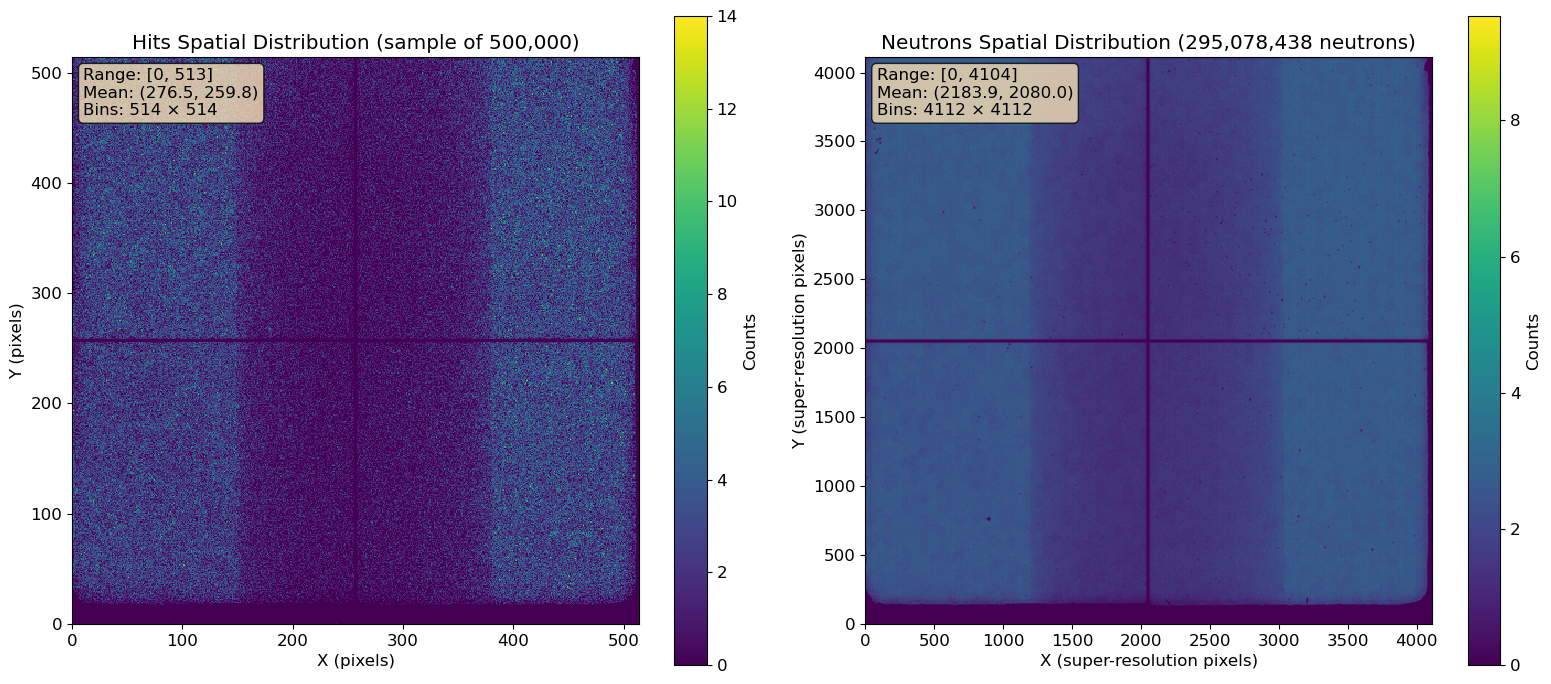


=== Spatial Distribution Analysis ===
Detector configuration: 514×514 pixels
Super-resolution factor: 8.0x

Hits (native pixels):
  X range: 0 - 513
  Y range: 0 - 513
  Total hits: 736,028,562

Neutrons (super-resolution pixels):
  X range: 0.0 - 4104.0
  Y range: 0.0 - 4104.0
  Total neutrons: 295,078,438
  Data reduction: 2.5:1


In [8]:
print("=== Creating spatial distribution visualizations ===")

# VENUS detector has 514x514 pixels (256*2 + 2 pixel gap)
DETECTOR_PIXELS = det_venus_config.get_chip_size_x() * 2 + 2

# use super-resolution factor from config
NEUTRON_SUPER_RES = config.centroid.super_resolution_factor

# Create figure with two subplots for better comparison
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

# Plot 1: Hits distribution (native pixels)
print("\nCreating hits 2D histogram...")
# Sample hits for performance
sample_size = 500000
indices = np.random.choice(len(hits), sample_size, replace=False)
hits_x_sample = hits["x"][indices]
hits_y_sample = hits["y"][indices]

# Use 514 bins for native pixel data (one bin per detector pixel)
hist_hits, x_edges, y_edges = np.histogram2d(
    hits_x_sample,
    hits_y_sample,
    bins=DETECTOR_PIXELS,
    range=[[0, DETECTOR_PIXELS], [0, DETECTOR_PIXELS]],
)

im1 = ax1.imshow(
    hist_hits,
    origin="lower",
    aspect="equal",
    extent=[0, DETECTOR_PIXELS, 0, DETECTOR_PIXELS],
    cmap="viridis",
    interpolation="none",
)
ax1.set_xlabel("X (pixels)")
ax1.set_ylabel("Y (pixels)")
ax1.set_title(f"Hits Spatial Distribution (sample of {sample_size:,})")
plt.colorbar(im1, ax=ax1, label="Counts")

# Add statistics
stats_text = f"Range: [{hits_x_sample.min()}, {hits_x_sample.max()}]\n"
stats_text += f"Mean: ({hits_x_sample.mean():.1f}, {hits_y_sample.mean():.1f})\n"
stats_text += f"Bins: {DETECTOR_PIXELS} × {DETECTOR_PIXELS}"
ax1.text(
    0.02,
    0.98,
    stats_text,
    transform=ax1.transAxes,
    verticalalignment="top",
    bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.8),
)

# Plot 2: Neutrons distribution (super-resolution pixels)
print("Creating neutrons 2D histogram...")
# Use detector and clustering configuration to determine bins
NEUTRON_BINS = int(DETECTOR_PIXELS * NEUTRON_SUPER_RES)
neutrons_x = neutrons["x"]
neutrons_y = neutrons["y"]
x_min, x_max = neutrons_x.min(), neutrons_x.max()
y_min, y_max = neutrons_y.min(), neutrons_y.max()

hist_neutrons, x_edges_n, y_edges_n = np.histogram2d(
    neutrons_x,
    neutrons_y,
    bins=NEUTRON_BINS,
    range=[[0, NEUTRON_BINS], [0, NEUTRON_BINS]],
    # range=[[x_min, x_max], [y_min, y_max]],
)

im2 = ax2.imshow(
    np.log1p(hist_neutrons),
    origin="lower",
    aspect="equal",
    extent=[0, NEUTRON_BINS, 0, NEUTRON_BINS],
    # extent=[x_min, x_max, y_min, y_max],
    cmap="viridis",
    interpolation="gaussian",  # this is critical when we have too many 1 hit neutrons
)
ax2.set_xlabel("X (super-resolution pixels)")
ax2.set_ylabel("Y (super-resolution pixels)")
ax2.set_title(f"Neutrons Spatial Distribution ({len(neutrons):,} neutrons)")
plt.colorbar(im2, ax=ax2, label="Counts")

# Add statistics
stats_text = f"Range: [{neutrons_x.min():.0f}, {neutrons_x.max():.0f}]\n"
stats_text += f"Mean: ({neutrons_x.mean():.1f}, {neutrons_y.mean():.1f})\n"
stats_text += f"Bins: {NEUTRON_BINS} × {NEUTRON_BINS}"
ax2.text(
    0.02,
    0.98,
    stats_text,
    transform=ax2.transAxes,
    verticalalignment="top",
    bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.8),
)

plt.tight_layout()
plt.show()

# Print detailed statistics
print("\n=== Spatial Distribution Analysis ===")
print(f"Detector configuration: {DETECTOR_PIXELS}×{DETECTOR_PIXELS} pixels")
print(f"Super-resolution factor: {NEUTRON_SUPER_RES}x")

print("\nHits (native pixels):")
print(f"  X range: {hits['x'].min()} - {hits['x'].max()}")
print(f"  Y range: {hits['y'].min()} - {hits['y'].max()}")
print(f"  Total hits: {len(hits):,}")

print("\nNeutrons (super-resolution pixels):")
print(f"  X range: {neutrons_x.min():.1f} - {neutrons_x.max():.1f}")
print(f"  Y range: {neutrons_y.min():.1f} - {neutrons_y.max():.1f}")
print(f"  Total neutrons: {len(neutrons):,}")
print(f"  Data reduction: {len(hits) / len(neutrons):.1f}:1")

## 8. TOF Analysis

=== TOF Analysis ===
TOF ranges:
  Hits: 0.000 - 16.666 ms
  Neutrons: 0.000 - 16.666 ms


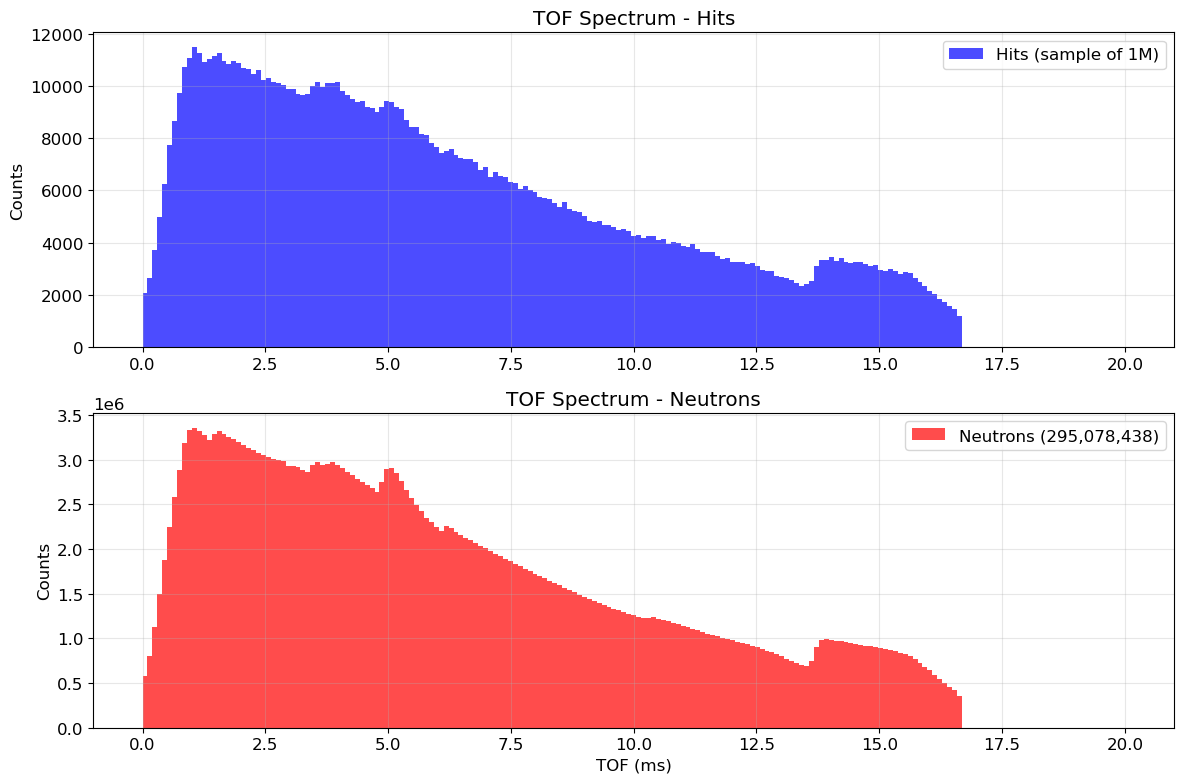

In [9]:
print("=== TOF Analysis ===")

# Convert TOF to milliseconds
hits_tof_ms = hits["tof"] * 25 / 1e6  # 25ns units to ms
neutrons_tof = neutrons["tof"]
neutrons_tof_ms = neutrons_tof * 25 / 1e6

print(f"TOF ranges:")
print(f"  Hits: {hits_tof_ms.min():.3f} - {hits_tof_ms.max():.3f} ms")
print(f"  Neutrons: {neutrons_tof_ms.min():.3f} - {neutrons_tof_ms.max():.3f} ms")

# Create TOF spectra
tof_bins = np.linspace(0, 20, 200)  # 0-20 ms in 200 bins

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))

# Hits TOF spectrum (sample for performance)
sample_indices = np.random.choice(len(hits_tof_ms), 1000000, replace=False)
ax1.hist(
    hits_tof_ms[sample_indices],
    bins=tof_bins,
    alpha=0.7,
    label=f"Hits (sample of 1M)",
    color="blue",
)
ax1.set_ylabel("Counts")
ax1.set_title("TOF Spectrum - Hits")
ax1.legend()
ax1.grid(True, alpha=0.3)

# Neutrons TOF spectrum
ax2.hist(
    neutrons_tof_ms,
    bins=tof_bins,
    alpha=0.7,
    label=f"Neutrons ({len(neutrons_tof_ms):,})",
    color="red",
)
ax2.set_xlabel("TOF (ms)")
ax2.set_ylabel("Counts")
ax2.set_title("TOF Spectrum - Neutrons")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 9. Summary and Verification

In [10]:
print("=== Clustering Verification Summary ===")
print()
print("✅ TPX3 file processing: SUCCESS")
print(f"   - Processed {len(hits):,} hits in {processing_time:.2f} seconds")
print(f"   - Rate: {len(hits) / processing_time / 1e6:.1f} M hits/second")
print()
print("✅ Clustering pipeline: SUCCESS")
print(f"   - Input: {len(hits):,} hits")
print(f"   - Output: {len(neutrons):,} neutrons")
print(f"   - Efficiency: {efficiency:.6f} ({efficiency * 100:.4f}%)")
print(f"   - Processing time: {clustering_time:.2f} seconds")
print()
print("✅ Sub-pixel precision: CONFIRMED")
print(f"   - {non_integer_x:,} neutrons have non-integer X coordinates")
print(f"   - {non_integer_y:,} neutrons have non-integer Y coordinates")
print()
print("✅ Cluster analysis: COMPLETE")
print(f"   - Mean cluster size: {n_hits_field.mean():.1f} hits")
print(f"   - Cluster size range: {n_hits_field.min()} - {n_hits_field.max()} hits")
print(
    f"   - Multi-hit clusters: {multi_hit:,} ({100 * multi_hit / len(neutrons):.1f}%)"
)

=== Clustering Verification Summary ===

✅ TPX3 file processing: SUCCESS
   - Processed 736,028,562 hits in 40.52 seconds
   - Rate: 18.2 M hits/second

✅ Clustering pipeline: SUCCESS
   - Input: 736,028,562 hits
   - Output: 295,078,438 neutrons
   - Efficiency: 0.400906 (40.0906%)
   - Processing time: 77.22 seconds

✅ Sub-pixel precision: CONFIRMED
   - 143,884,882 neutrons have non-integer X coordinates
   - 123,512,738 neutrons have non-integer Y coordinates

✅ Cluster analysis: COMPLETE
   - Mean cluster size: 2.5 hits
   - Cluster size range: 1 - 85 hits
   - Multi-hit clusters: 188,746,313 (64.0%)
